<a href="https://colab.research.google.com/github/Ruxicommits/kaggle_projects/blob/main/petrol_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
from google.colab import drive

## Petrol prices in India

In this notebook we are going to discuss the collection of dataset available on the kaggle platform.

The data is published under the CC0 license on [this kaggle page](https://www.kaggle.com/syedjaferk/petrol-price-data-by-district).

Let's get familiar with the content of the notebook and follow the instructions to prepare the data that we are going to need during classes.

**Note!** When you come back to the document later, remember to re-run the code cells.

### Dataset contents

In this case we're importing information on:
*   **city** - where the corresponding price was recorded,
*   **date** - when the price was recorded,
*   **rate** - the price of petrol,
*   **district** - the part of India where the city is.



The necessary data is provided with the document: the code below imports the file.

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
petrol_prices = pd.read_csv('/content/drive/My Drive/Vis/Petrol Prices/petrol_prices.csv')
petrol_prices

,city,date,rate,district
0,Chittoor,2016-07-01,70.75,Andhra Pradesh
1,Chittoor,2016-07-15,68.43,Andhra Pradesh
2,Chittoor,2016-08-01,67.06,Andhra Pradesh
3,Chittoor,2016-08-15,66.08,Andhra Pradesh
4,Chittoor,2016-09-01,69.56,Andhra Pradesh
...,...,...,...,...
21679,Kadapa,2021-02-25,96.12,Andhra Pradesh
21680,Kadapa,2021-02-26,96.12,Andhra Pradesh
21681,Kadapa,2021-02-27,96.36,Andhra Pradesh
21682,Kadapa,2021-02-28,96.36,Andhra Pradesh


## Notebook preparation

We want to start by making sure that the data has been correctly identified and make necessary conversions.

Based on data overview, we expect that the first and last columns contain text-based data. We assume that the **date** column should only contain dates, and **rate** - only numeric values.

Let's check what the actual content of the set is.

### Checking data types

Below, we need to run the listed instructions to get the DataFrames used during classes.

Let's first check how the data was identified on import.

In [27]:
petrol_prices.dtypes

,0
city,object
date,datetime64[ns]
rate,float64
district,category


Not unlike with the other datasets, we need to verify if the data has records where any of the columns is missing information.

In [5]:
"complete records: " + str(len(petrol_prices.dropna(how="any"))) + "; total records: " + str(len(petrol_prices))

'complete records: 21684; total records: 21684'

### Date conversion

In the **date** column, we need to convert the data so that it is correctly identified as dates.

In [6]:
petrol_prices["date"] = pd.to_datetime(petrol_prices["date"])

We should also check if all of the dates occur the same number of times in the set: if they don't we can expect that for some cities we don't have information for the entire period.

In [7]:
petrol_prices["date"].value_counts()

,count
date,
2016-11-06,25
2016-11-16,25
2019-08-27,25
2017-10-04,25
2020-02-09,24
...,...
2019-01-08,1
2011-12-01,1
2019-07-11,1


### Identifying city names in the set

Next, let's look at the contents of the **city** column.

In [8]:
petrol_prices["city"].value_counts()

,count
city,
Chandigarh,1044
Hyderabad,1036
Daman,964
Silvassa,964
Itanagar,920
Port Blair,916
Golaghat,880
Vizag,880
Guntur,880


Note that the set contains groups of cities with a similar number of observations. We can expect to have interesting results when we compare observations for:
*   Chandigarh and Hyderabad,
*   Silvassa and Daman,
*   Itanagar and Port Blair,
*   Vizag, Guntur, Araria, Golaghat and Ambikapur,
*   Groups of cities with 876 observations,

if we are dealing with similar periods.


### Identifying district names in the set

The next column we want to have a closer look at, is **district**.

In [9]:
petrol_prices["district"].value_counts()

,count
district,
Andhra Pradesh,12428
Assam,2632
Chandigarh,1044
Dadra and Nagar Haveli,964
Daman and Diu,964
Arunachal Pradesh,920
Andaman and Nicobar Islands,916
Chhattisgarh,880
Bihar,880


in this case we'll change the type of data to a category.

In [10]:
petrol_prices["district"] = petrol_prices["district"].astype("category")

### Price statistics

Finally, let's look at the statistics of recorded prices.

In [11]:
petrol_prices.describe()

,date,rate
count,21684,21684.000000
mean,2019-07-19 17:19:25.467625984,77.714397
min,2011-11-16 00:00:00,48.600000
25%,2018-09-17 00:00:00,73.650000
50%,2019-11-05 00:00:00,77.150000
75%,2020-07-19 00:00:00,83.620000
max,2021-03-01 00:00:00,97.850000
std,NaN,7.312926


## Exercises

Make sure the seaborn library is imported, set the theme, context, and the color palette.

Create a line plot that illustrates how fuel prices evolved during the period we research. In the following columns, have the plots for individual districts, with the maximum number of columns in a row set to 5. Additionally, use color to differentiate the lines for different districts.

In [32]:
sns.set_theme(style="whitegrid", palette='viridis')
sns.set_context("notebook", font_scale=1.5)

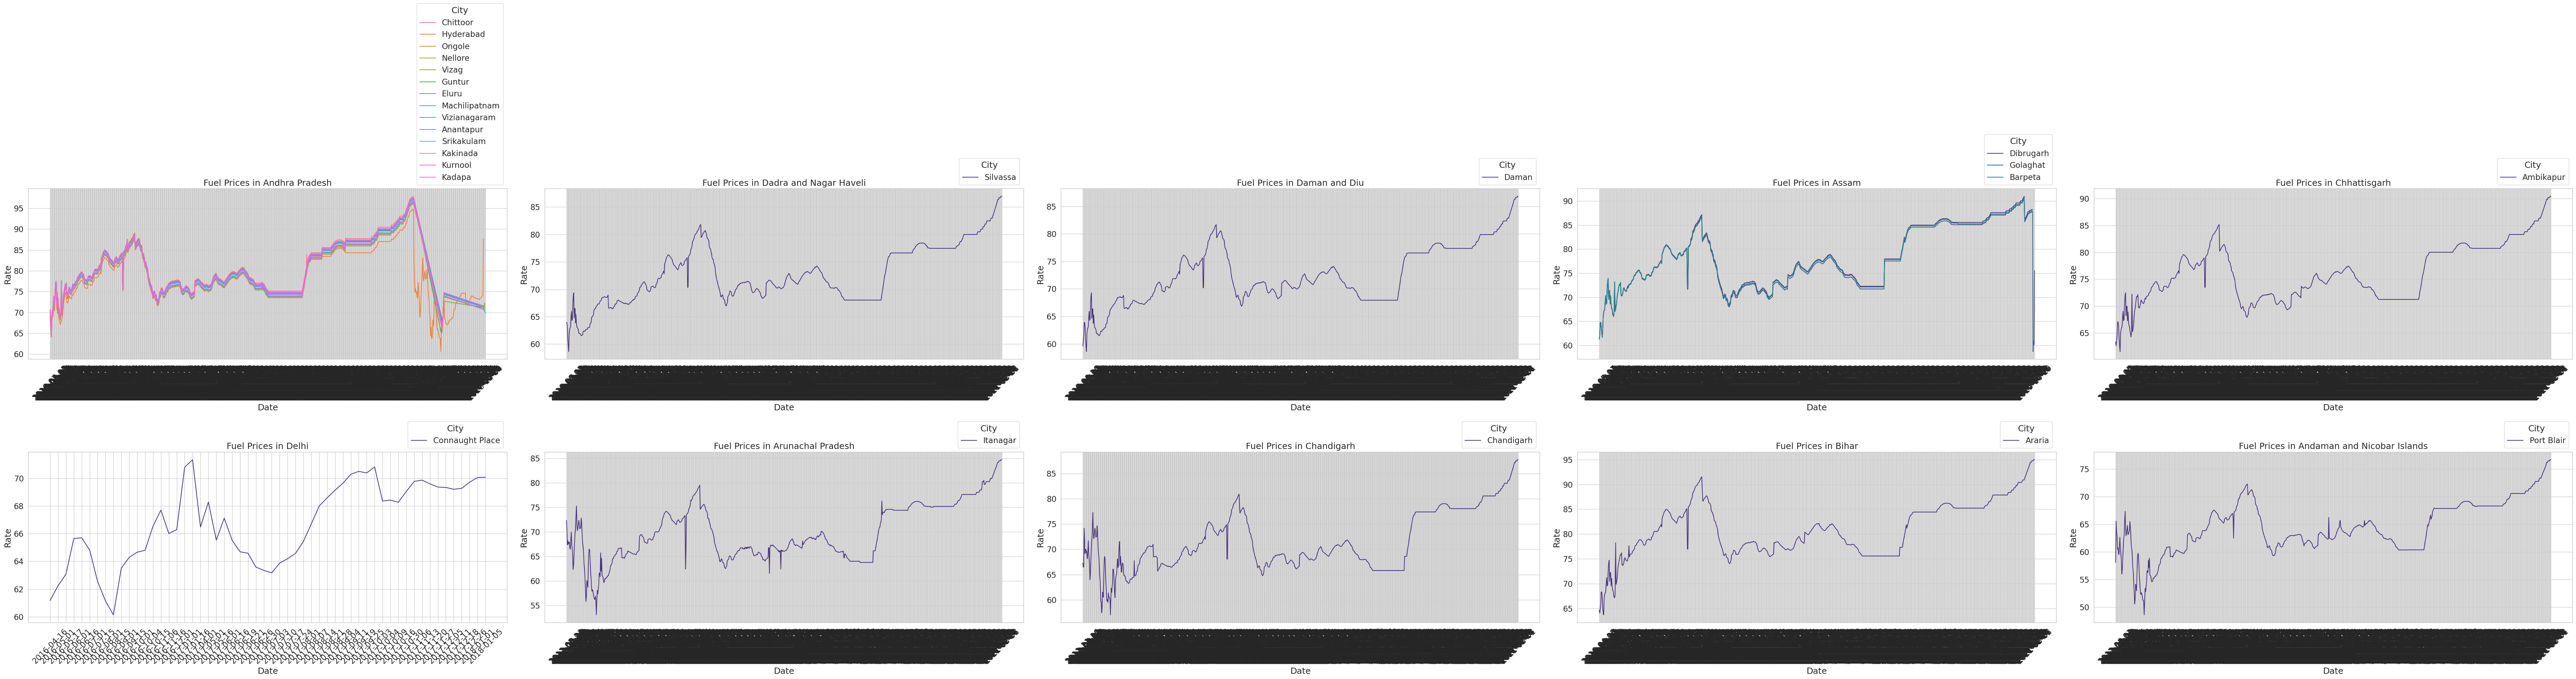

In [36]:
import matplotlib.pyplot as plt

# Get unique districts
districts = petrol_prices['district'].unique()
num_districts = len(districts)

# Determine grid dimensions (max 5 columns)
num_cols = min(num_districts, 5)
num_rows = (num_districts + num_cols - 1) // num_cols # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 15, num_rows * 10), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, district in enumerate(districts):
    ax = axes[i]
    district_data = petrol_prices[petrol_prices['district'] == district]
    sns.lineplot(data=district_data, x='date', y='rate', hue='city', ax=ax, errorbar=None)
    ax.set_title(f'Fuel Prices in {district}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='City', loc='lower right', bbox_to_anchor=(1, 1))

# Hide any unused subplots
for j in range(num_districts, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

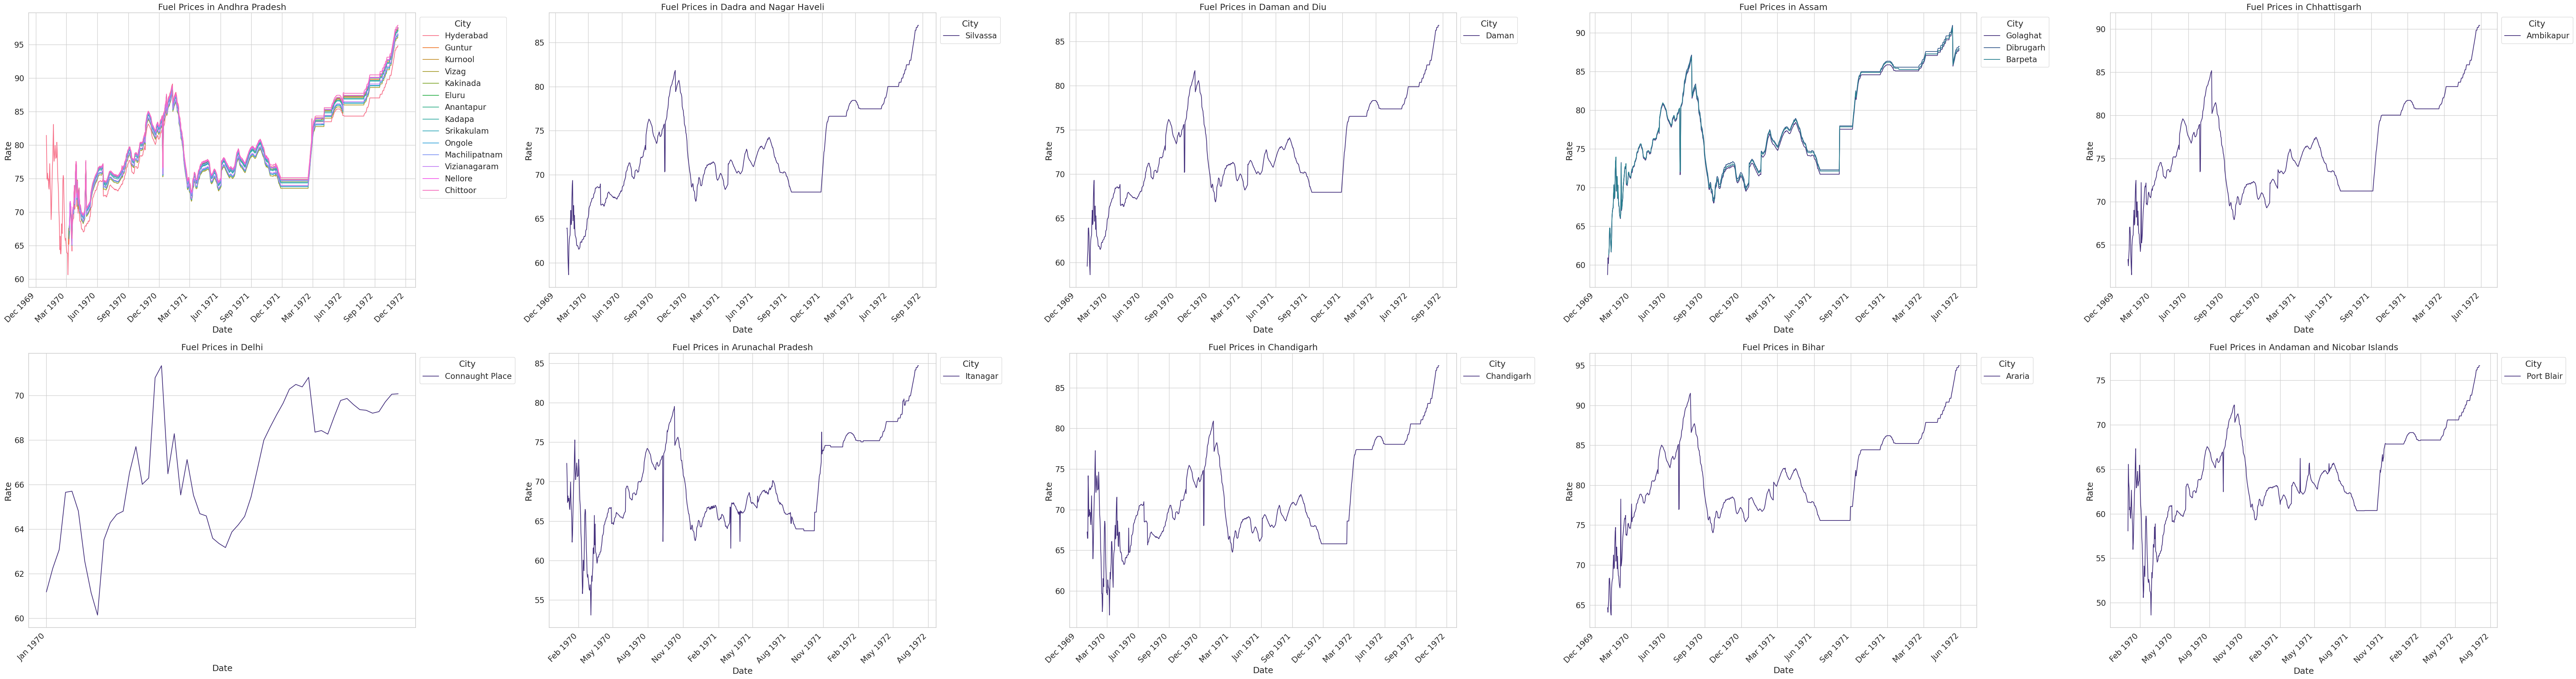

In [38]:
import matplotlib.pyplot as plt

# Get unique districts
districts = petrol_prices['district'].unique()
num_districts = len(districts)

# Determine grid dimensions (max 5 columns)
num_cols = min(num_districts, 5)
num_rows = (num_districts + num_cols - 1) // num_cols # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 15, num_rows * 10), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration


import matplotlib.dates as mdates

for i, district in enumerate(districts):
    ax = axes[i]
    district_data = petrol_prices[petrol_prices['district'] == district].sort_values('date')
    sns.lineplot(data=district_data, x='date', y='rate', hue='city', ax=ax, errorbar=None)
    ax.set_title(f'Fuel Prices in {district}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rate')

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.legend(title='City', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Let's stay on the topic of fuels in India. In this exercise, we will consider the most frequent values of fuel prices during the period we research.

1. Go to the petrol prices notebook.
2. Create a histogram that illustrates how fuel prices evolved during the period.
3. Add a KDE line to the plot and consider whether it:
-influences the interpretation of the result,

-is helpful?

4. Replace the histogram with the KDE plot and decide which chart best reflects the information you are looking for.

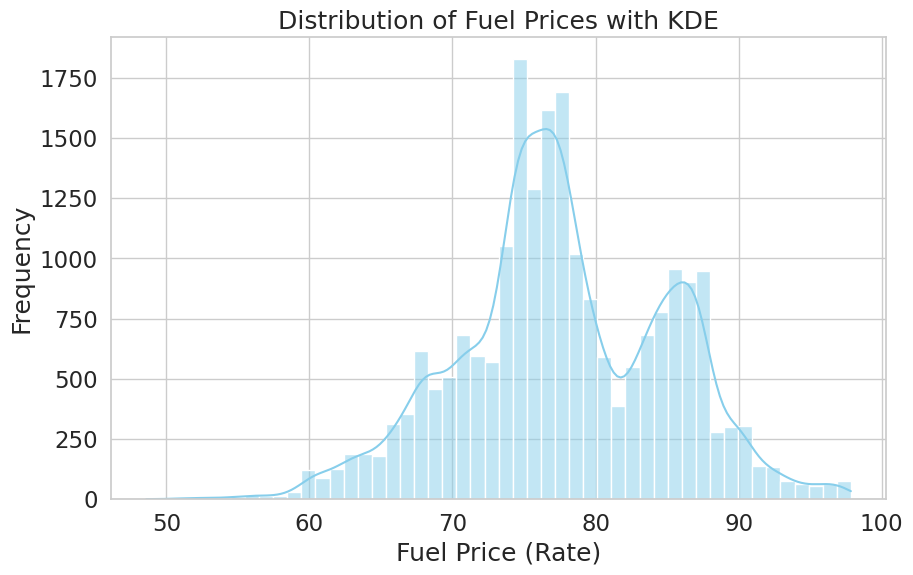

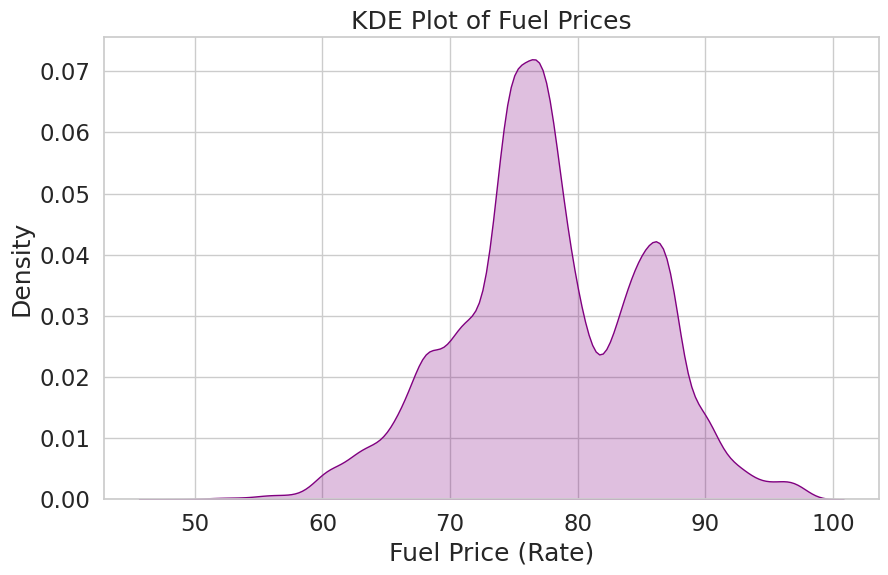

In [14]:
import matplotlib.pyplot as plt

# Create a histogram with a KDE line
plt.figure(figsize=(10, 6))
sns.histplot(petrol_prices['rate'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Fuel Prices with KDE')
plt.xlabel('Fuel Price (Rate)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Create a KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(petrol_prices['rate'], fill=True, color='purple')
plt.title('KDE Plot of Fuel Prices')
plt.xlabel('Fuel Price (Rate)')
plt.ylabel('Density')
plt.grid(True)
plt.show()